# Neural Network

## Introduction


*  In fact, Logistic Regression (that have learned in our last session) is the simplest form of Neural Network; Artificial neural networks can be viewed as an extension of Logistic Regression
*  Logistic Regression: results in decision boundaries that are a straight line
*  Neural Networks: can generate more complex decision boundaries
*  (Deep) Neural Networks: a universal approximator!
* In this session, we will learn to use PyTorch for digit recognition


## Importing the libraries

In [1]:
%matplotlib inline
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt  # plotting library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Importing the dataset

- MNIST is a collection of handwritten digits ranging from the number 0 to 9. 

- It has a training set of 60,000 images, and 10,000 test images that are classified into corresponding categories or labels. 

### CSV Format

The MNIST dataset is provided as CSV files where each row represents a flattened 28×28 grayscale image (784 pixel values) and a label (0‑9). We'll load these files using pandas.

In [2]:
# Load dataset from local CSV files
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

# Separate labels and pixel values
x_train = train_data.iloc[:, 1:].values.astype('float32')
y_train = train_data.iloc[:, 0].values.astype('int64')
x_test = test_data.iloc[:, 1:].values.astype('float32')
y_test = test_data.iloc[:, 0].values.astype('int64')

In [3]:
# count the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

# count the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {np.int64(0): np.int64(600), np.int64(1): np.int64(600), np.int64(2): np.int64(600), np.int64(3): np.int64(600), np.int64(4): np.int64(600), np.int64(5): np.int64(600), np.int64(6): np.int64(600), np.int64(7): np.int64(600), np.int64(8): np.int64(600), np.int64(9): np.int64(600)}

Test labels:  {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


## Data visualization

- Let's sample the 25 random MNIST digits and visualize them.

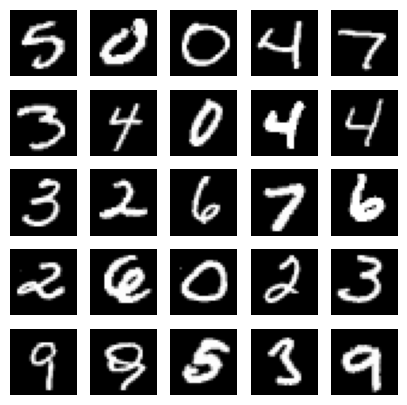

In [4]:
# sample 25 mnist digits from train dataset
indexes = np.random.randint(0, x_train.shape[0], size=25)
images = x_train[indexes]
labels = y_train[indexes]

# plot the 25 mnist digits
plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    plt.subplot(5, 5, i + 1)
    image = images[i]
    image = image.reshape(28, 28)  # MNIST images are 28x28
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    
plt.show()


## Designing model architecture using PyTorch

## Import PyTorch modules

In [5]:
# PyTorch modules already imported earlier
# If needed, you can import them again:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset


## Compute the number of labels

In [6]:
num_labels = len(np.unique(y_train))

## One-Hot Encoding

- At this point, the labels are in digits format, 0 to 9. 
- A more suitable format is called a one-hot vector, a 10-dim vector with all elements 0, except for the index of the digit class. 
- For example, if the label is 2, the equivalent one-hot vector is [0,0,1,0,0,0,0,0,0,0]. The first label has index 0.

In [7]:
# In PyTorch, we don't need one-hot encoding for CrossEntropyLoss.
# The loss function expects integer class labels (0-9).
# y_train and y_test already contain integer labels.
# If you need one-hot encoding for other purposes, you can use:
# y_train_onehot = torch.nn.functional.one_hot(torch.tensor(y_train), num_classes=10).float()
# y_test_onehot = torch.nn.functional.one_hot(torch.tensor(y_test), num_classes=10).float()


## Data Preprocessing 

In [8]:
# image dimensions (assumed square)
image_size = int(np.sqrt(x_train.shape[1]))  # 28
input_size = image_size * image_size  # 784
input_size

784

In [9]:
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

## Setting network parameters

- The **batch_size** argument indicates the number of data that we will use for each update of the model parameters.

- **Hidden_units** shows the number of hidden units.

- **Dropout** is the dropout rate (related to **Overfitting and Regularization**).

In [10]:
# network parameters
batch_size = 128
hidden_units = 256
dropout = 0.45

## Designing the model architecture

### Multi‑Layer Perceptron (MLP)

We'll build a simple feed‑forward neural network with three fully‑connected (linear) layers:

1. **Input layer** → 784 neurons (one per pixel)
2. **Hidden layer 1** → 512 neurons with ReLU activation and dropout
3. **Hidden layer 2** → 512 neurons with ReLU activation and dropout
4. **Output layer** → 10 neurons (one per digit) with no activation (logits)

Dropout randomly sets a fraction of neurons to zero during training, which helps prevent overfitting.

In [11]:
# Define a 3-layer MLP with ReLU and dropout after each layer
class MLP(nn.Module):
    def __init__(self, input_size, hidden_units, num_labels, dropout):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, num_labels)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # No activation here, we'll apply softmax in loss
        return x

# Instantiate the model
model = MLP(input_size, hidden_units, num_labels, dropout)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.45, inplace=False)
)


## View model summary

- PyTorch models can be printed to see the layer structure. We can also compute the number of parameters.

In [12]:
# Print model architecture
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.45, inplace=False)
)
Total parameters: 269,322
Trainable parameters: 269,322


## How big is our model (number of parameters)?

- From input to Dense layer: 784 × 256 + 256 = 200,960. 

- From first Dense to second Dense: 256 × 256 + 256 = 65,792. 

- From second Dense to the output layer: 10 × 256 + 10 = 2,570. 

- The total is 200,690 + 65,972 + 2,570 = 269,322.

## Compile the model with compile() method

In [13]:
# Convert data to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # labels are integer class indices
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader for batch processing
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # combines LogSoftmax and NLLLoss, expects raw logits
optimizer = optim.Adam(model.parameters())

## Loss function (CrossEntropyLoss)

- How far the predicted tensor is from the true class labels is called **loss**.

- In this example, we use **CrossEntropyLoss** as the loss function. It combines a log‑softmax activation and negative log‑likelihood loss, and expects raw logits (no softmax applied in the model's output).

- PyTorch provides many other loss functions, such as `MSELoss`, `BCELoss`, `L1Loss`, etc. The choice of the loss function should match the task (classification, regression, etc.).

- For multi‑class classification, `CrossEntropyLoss` is the standard choice. For binary classification, `BCELoss` (with sigmoid activation) can be used.

## Optimization (optimizer Adam)

- With optimization, the objective is to minimize the loss function. The idea is that if the loss is reduced to an acceptable level, the model has indirectly learned the function mapping input to output.

- PyTorch provides many optimizers in `torch.optim`. The most commonly used optimizers are: **Stochastic Gradient Descent (SGD)**, **Adaptive Moments (Adam)**, and **Root Mean Squared Propagation (RMSprop)**.

- Each optimizer features tunable parameters like learning rate, momentum, and weight decay.

- Adam and RMSprop are variations of SGD with adaptive learning rates. In this classifier network, we use Adam because it often converges quickly and works well for a wide range of problems.

## Metrics (accuracy)

- Performance metrics are used to determine if a model has learned the underlying data distribution. The primary metric we monitor during training is the loss.

- During training, validation, and testing, we can also compute additional metrics such as **accuracy**.

- **Accuracy** is the percent, or fraction, of correct predictions based on ground truth. In PyTorch we compute it manually by comparing predicted class indices with true labels.

## Train the model with a custom training loop

### Steps in a Training Loop

Each epoch consists of:

1. **Forward pass**: Compute predictions (logits) from the input batch.
2. **Compute loss**: Compare predictions with true labels using cross‑entropy.
3. **Backward pass**: Compute gradients of the loss with respect to all model parameters.
4. **Optimizer step**: Update the parameters using the gradients (Adam).
5. **Metrics**: Accumulate loss and accuracy for the epoch.

We repeat this for every batch in the training set, then print the average loss and accuracy.

In [14]:
# Training loop
epochs = 20
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()  # set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()  # zero the gradients
        outputs = model(batch_x)  # forward pass
        loss = criterion(outputs, batch_y)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update weights
        
        running_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - accuracy: {epoch_accuracy:.4f}')

Epoch 1/20 - loss: 1.3396 - accuracy: 0.5907


Epoch 2/20 - loss: 0.5413 - accuracy: 0.8352


Epoch 3/20 - loss: 0.3841 - accuracy: 0.8838


Epoch 4/20 - loss: 0.3254 - accuracy: 0.9045


Epoch 5/20 - loss: 0.2745 - accuracy: 0.9200


...

Epoch 16/20 - loss: 0.0820 - accuracy: 0.9722


Epoch 17/20 - loss: 0.0737 - accuracy: 0.9767


Epoch 18/20 - loss: 0.0726 - accuracy: 0.9780


Epoch 19/20 - loss: 0.0590 - accuracy: 0.9813


Epoch 20/20 - loss: 0.0556 - accuracy: 0.9835


## Evaluating model performance on the test set

### Evaluation Mode

During evaluation we:

1. Switch the model to `eval()` mode (disables dropout and batch‑norm).
2. Disable gradient computation with `torch.no_grad()` for efficiency.
3. Iterate over the test set, compute loss and accuracy.
4. Report the final test loss and accuracy.

This gives us an unbiased estimate of how well the model generalizes to unseen data.

In [15]:
# Evaluate on test set
model.eval()  # set model to evaluation mode
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():  # disable gradient computation
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

test_loss = test_loss / total
test_accuracy = correct / total
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f} ({100.0 * test_accuracy:.1f}%)')

Test loss: 0.2599
Test accuracy: 0.9230 (92.3%)


## Neural Network from scratch

- It's for the code session!

## Acknowledgments

Thanks to PRASHANT BANERJEE for creating the open-source [Kaggle jupyter notebook](https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras), licensed under Apache 2.0. It inspires the majority of the content of this slides.